# Shopstream - Customer_Lifetime_Value - Regression

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [11]:
df = pd.read_csv('ecommerce_orders_dataset.csv')

In [12]:
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [13]:
df.shape

(30000, 41)

In [14]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

In [16]:
# Categorical columns requiring Label Encoding

categorical_cols = [
    'Customer_Gender', 'Country', 'City', 'Customer_Segment', 
    'Product_Category', 'Product_Subcategory', 'Brand', 'Coupon_Used', 
    'Payment_Method', 'Device_Type', 'Traffic_Source', 'Membership_Status', 
    'Shipping_Method', 'Warehouse_Region', 'Order_Status', 'Returned', 
    'Season', 'Holiday_Season', 'High_Value_Order'
]

In [17]:
# Apply Label Encoding and keep a dictionary of encoders

label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [24]:
df_encoded.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

## Regression Models: Linear Regression & Regularization

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
features = [
    'Customer_Age', 'Customer_Gender', 'Country', 'Customer_Segment', 
    'Product_Category', 'Brand', 'Unit_Price', 'Quantity', 'Discount_Percent', 
    'Shipping_Cost', 'Payment_Method', 'Device_Type', 'Traffic_Source', 
    'Membership_Status', 'Shipping_Method', 'Warehouse_Region', 'Season', 'Holiday_Season',
    'Profit_Amount'
]

In [30]:
X = df_encoded[features]
y = df_encoded['Customer_Lifetime_Value']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# Defining linear models

linear_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2 Regularized)': Ridge(alpha=10.0),
    'Lasso (L1 Regularized)': Lasso(alpha=0.5),
    'Elastic Net': ElasticNet(alpha=0.5, l1_ratio=0.5)
}

In [34]:
# Training and Evaluation

for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"[{name}] -> R2 Score: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

[Linear Regression] -> R2 Score: 0.6970 | MAE: 1970.15 | RMSE: 3561.84
[Ridge (L2 Regularized)] -> R2 Score: 0.6970 | MAE: 1969.85 | RMSE: 3561.84
[Lasso (L1 Regularized)] -> R2 Score: 0.6970 | MAE: 1969.91 | RMSE: 3561.81
[Elastic Net] -> R2 Score: 0.6830 | MAE: 1924.81 | RMSE: 3643.56


In [35]:
# We see from the results above that the Linear Regression Model gives a relatively low R2-score of 0.6970

# At the same time, the regularization techniques also do not improve these scores by much.

## Tree-Based & Boosting Regression Models

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

In [48]:
# Creating a dictionary for the tree models

tree_models = {
    'Decision Tree Regressor': DecisionTreeRegressor(
        max_depth=10, random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    'LightGBM Regressor': LGBMRegressor(
        max_depth=10, random_state=42, verbose=-1
    ),
}

In [60]:
# Training and evaluating models

for name, model in tree_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(
        f"[{name}] -> R2 Score: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}"
    )

# Creating a simple name for saving files
    model_name = name.lower().replace(" ", "_")

[Decision Tree Regressor] -> R2 Score: 0.6174 | MAE: 1835.57 | RMSE: 4002.80
[Random Forest] -> R2 Score: 0.7432 | MAE: 1667.44 | RMSE: 3279.24
[LightGBM Regressor] -> R2 Score: 0.7405 | MAE: 1664.01 | RMSE: 3296.29


In [51]:
# So, we see that the Decision Tree Regressor gives an even lesser R2-Score than the linear regression modlels.

# The LightGBM Regressor improves on that only a little, with an R2-score of 0.7405.

# The Random Forest Regressor gives the best R2-Score of 0.7432 with MAE=1667 and RMSE = 3279 

## Multi-Layer Perceptron (MLP) Neural Network for Regression

In [40]:
from sklearn.neural_network import MLPRegressor

In [41]:
mlp_regressor = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

In [42]:
mlp_regressor

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [43]:
mlp_regressor.fit(X_train_scaled, y_train)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [44]:
mlp_preds = mlp_regressor.predict(X_test_scaled)

In [45]:
r2_mlp = r2_score(y_test, mlp_preds)
mae_mlp = mean_absolute_error(y_test, mlp_preds)
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_preds))

print(f"[MLP Regressor] -> R2 Score: {r2_mlp:.4f} | MAE: {mae_mlp:.2f} | RMSE: {rmse_mlp:.2f}")

[MLP Regressor] -> R2 Score: 0.7581 | MAE: 1701.02 | RMSE: 3182.82


In [52]:
# So, we see that the MLP regressor gives a slightly improved R2-Score pf 0.7581.

In [ ]:
## However, since the MLP takes more time to execute, even as its R2-Score is only slightly better,
## we shall consider the Random Forest Regressor 

## Thus, the Random Forest Regressor is finalized to be used
## It yields the following evaluation metrics 
## R2 Score: 0.7432 | MAE: 1667.44 | RMSE: 3279.24

## Generating Plots

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [66]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

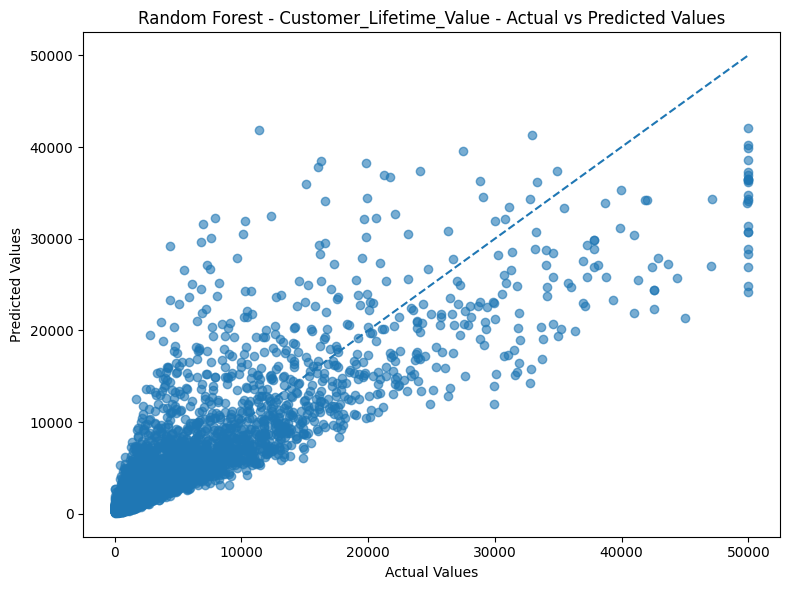

In [71]:
# Actual vs Predicted Values

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_preds, alpha=0.6)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest - Customer_Lifetime_Value - Actual vs Predicted Values")

plt.tight_layout()

plt.savefig(
    "random_forest_clv_actual_vs_predicted.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

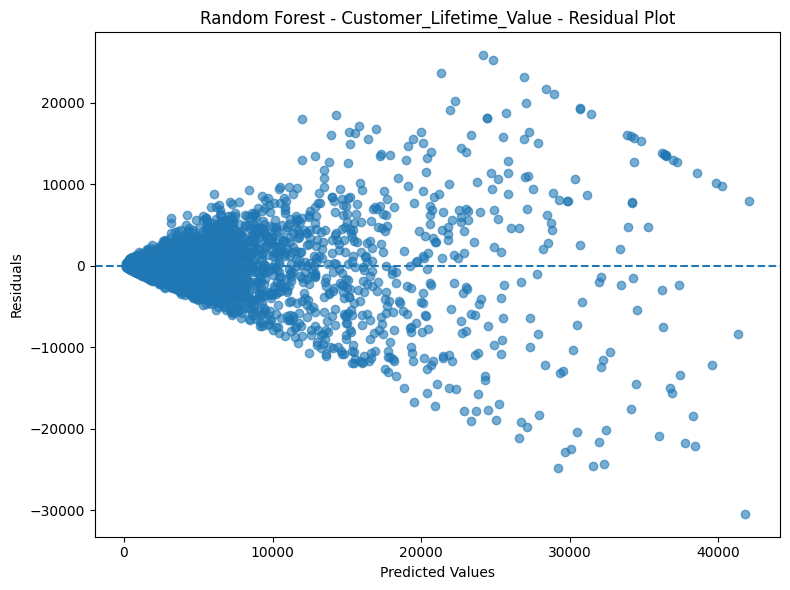

In [72]:
# Residual Plot

residuals = y_test - rf_preds

plt.figure(figsize=(8, 6))

plt.scatter(rf_preds, residuals, alpha=0.6)

# Zero residual reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Random Forest - Customer_Lifetime_Value - Residual Plot")

plt.tight_layout()

plt.savefig(
    "random_forest_clv_residual_plot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

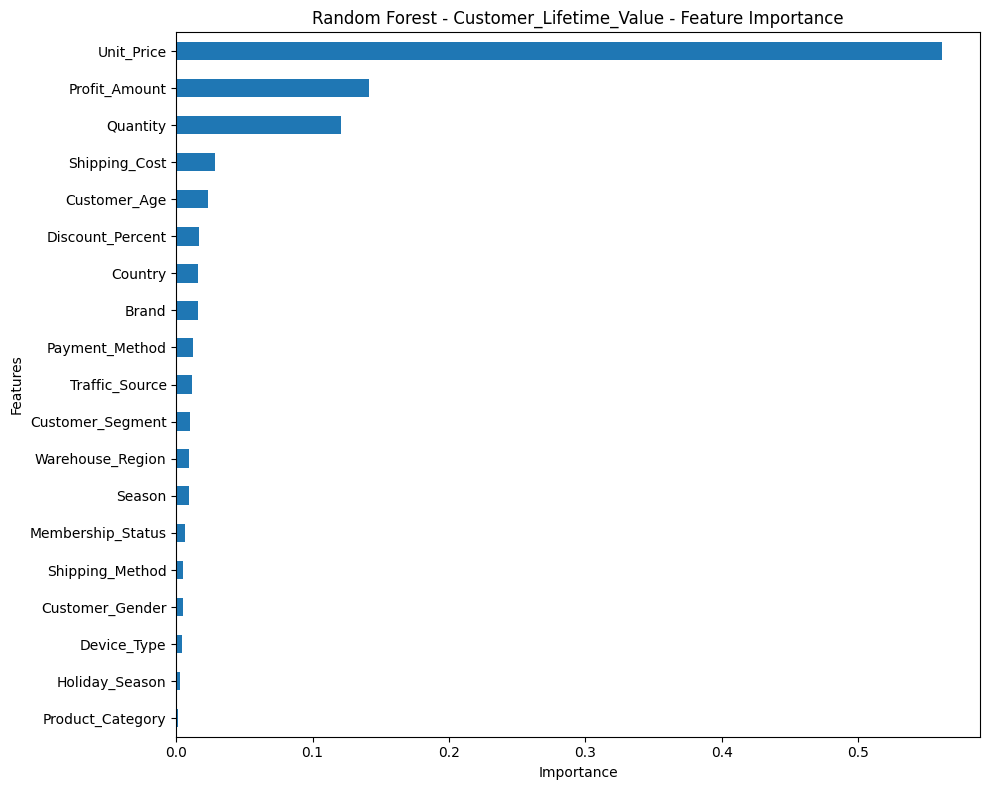

In [74]:
# Feature Importance

import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))

feature_importance.plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest - Customer_Lifetime_Value - Feature Importance")

plt.tight_layout()

plt.savefig(
    "random_forest_clv_feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

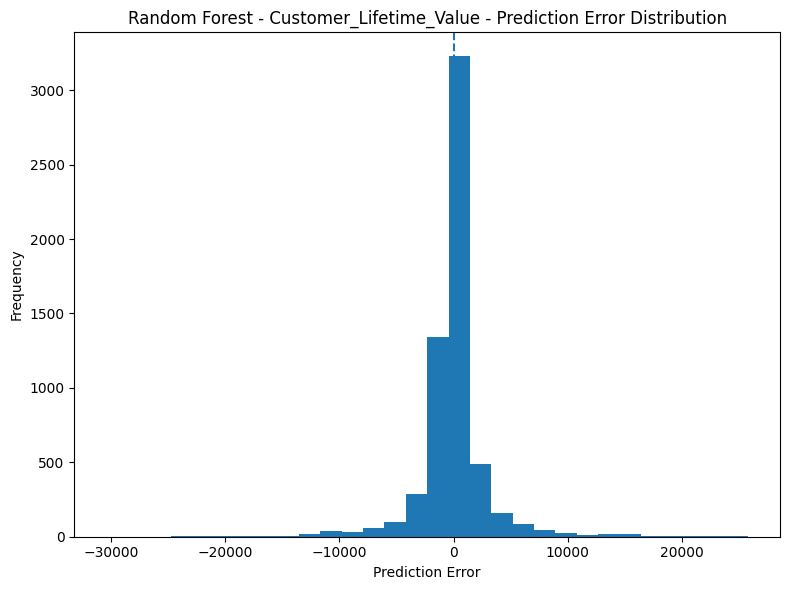

In [75]:
# Prediction Error Distribution

errors = y_test - rf_preds

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=30)

# Zero error reference line
plt.axvline(x=0, linestyle='--')

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Random Forest - Customer_Lifetime_Value - Prediction Error Distribution")

plt.tight_layout()

plt.savefig(
    "random_forest_clv_prediction_error_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()